In [ ]:
pip install tensorflow numpy pandas matplotlib seaborn scikit-learn

In [2]:
calorie_dict = {
    "pizza": 285,
    "hamburger": 295,
    "hot_dog": 290,
    "ice_cream": 207,
    "fried_rice": 238,
    "spaghetti_bolognese": 158,
    "sushi": 130,
    "donuts": 452,
    "apple_pie": 237,
    "cheesecake": 321
}

Dataset Found!
Found 101000 files belonging to 101 classes.
Using 80800 files for training.
Found 101000 files belonging to 101 classes.
Using 20200 files for validation.


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ ?                      │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,257,984 (8.61 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 2,257,984 (8.61 MB)

Epoch 1/5
2525/2525 ━━━━━━━━━━━━━━━━━━━━ 441s 172ms/step - accuracy: 0.3714 - loss: 2.6632 - val_accuracy: 0.4719 - val_loss: 2.1177
Epoch 2/5
2525/2525 ━━━━━━━━━━━━━━━━━━━━ 545s 216ms/step - accuracy: 0.4408 - loss: 2.3191 - val_accuracy: 0.4845 - val_loss: 2.1055
Epoch 3/5
2525/2525 ━━━━━━━━━━━━━━━━━━━━ 448s 177ms/step - accuracy: 0.4534 - loss: 2.2551 - val_accuracy: 0.4839 - val_loss: 2.1229
Epoch 4/5
2525/2525 ━━━━━━━━━━━━━━━━━━━━ 478s 189ms/step - accuracy: 0.4613 - loss: 2.2264 - val_accuracy: 0.4848 - val_loss: 2.1524
Epoch 5/5
2525/2525 ━━━━━━━━━━━━━━━━━━━━ 620s 246ms/step - accuracy: 0.4654 - loss: 2.2166 - val_accuracy: 0.4852 - val_loss: 2.1548


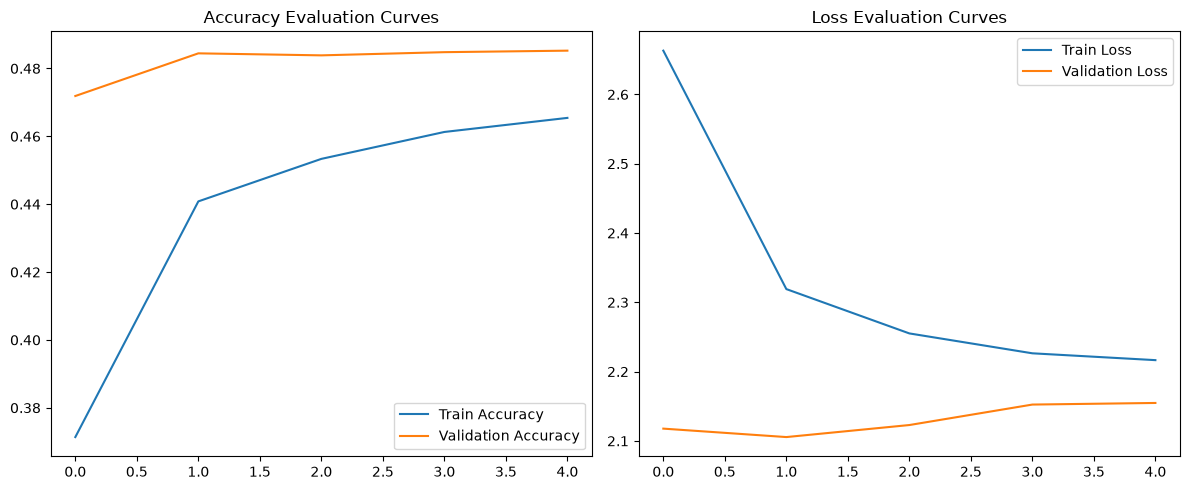

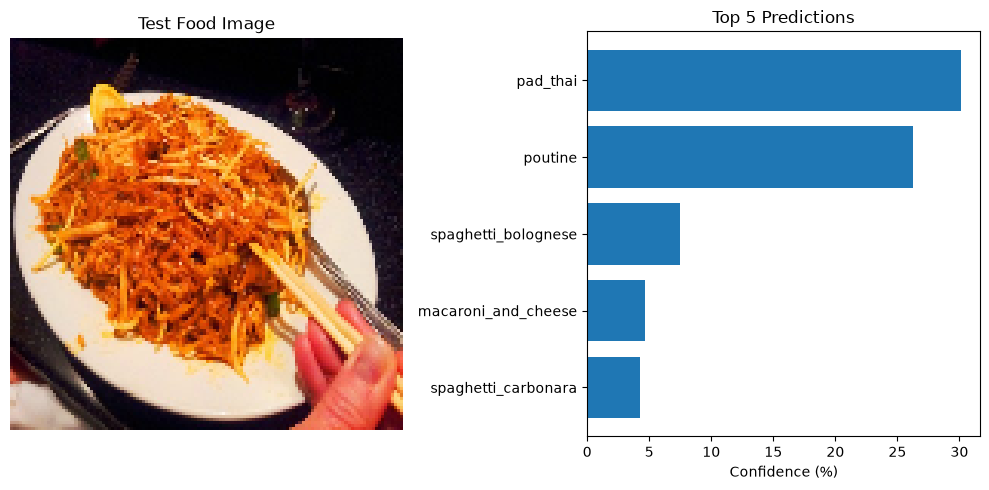

Model Saved Successfully!


In [6]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
import matplotlib.pyplot as plt
import numpy as np
import os

# DATASET PATH
dataset_path = r"D:\html basics\food-101\images"

# CHECK PATH
if not os.path.exists(dataset_path):
    raise Exception(f"Dataset path not found: {dataset_path}")

print("Dataset Found!")

# PARAMETERS
IMG_SIZE = (128, 128)
BATCH_SIZE = 32
EPOCHS = 5

# LOAD DATASET
train_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_ds.class_names

# OPTIMIZATION
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

# DATA AUGMENTATION
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

# BASE MODEL
base_model = MobileNetV2(
    input_shape=(128, 128, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

# FINAL MODEL
model = models.Sequential([
    data_augmentation,
    layers.Rescaling(1./127.5, offset=-1),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.2),
    layers.Dense(len(class_names), activation="softmax")
])

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# TRAIN MODEL
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS
)

# ACCURACY & LOSS GRAPH
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Accuracy Evaluation Curves")
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Loss Evaluation Curves")
plt.legend()

plt.tight_layout()
plt.savefig("accuracy_loss_graph.png")
plt.show()

# CALORIE DATABASE
calorie_dict = {
    "pizza": 285,
    "hamburger": 295,
    "hot_dog": 290,
    "ice_cream": 207,
    "fried_rice": 238,
    "spaghetti_bolognese": 158,
    "sushi": 130,
    "donuts": 452,
    "apple_pie": 237,
    "cheesecake": 321
}

# ==========================
# TOP 5 FOOD PREDICTIONS
# ==========================

for images, labels in val_ds.take(1):

    img = images[0]

    prediction = model.predict(
        tf.expand_dims(img,0),
        verbose=0
    )[0]

    top5_idx = np.argsort(prediction)[-5:][::-1]

    foods = [class_names[i] for i in top5_idx]
    probs = [prediction[i] * 100 for i in top5_idx]

    plt.figure(figsize=(10,5))

    plt.subplot(1,2,1)
    plt.imshow(img.numpy().astype("uint8"))
    plt.title("Test Food Image")
    plt.axis("off")

    plt.subplot(1,2,2)
    plt.barh(foods[::-1], probs[::-1])
    plt.xlabel("Confidence (%)")
    plt.title("Top 5 Predictions")

    plt.tight_layout()
    plt.savefig("food_prediction_result.png")
    plt.show()

    break

# SAVE MODEL
model.save("food_classifier.h5")

print("Model Saved Successfully!")